In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/online_retail.csv")

In [6]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(5225)

In [13]:
df = df.drop_duplicates()

In [14]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [15]:
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [16]:
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [17]:
df = df[df['Quantity'] > 0]

In [18]:
df = df[df['UnitPrice'] > 0]

In [19]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [39]:
### Visualization 1: Top 10 Countries by Transactions
df['Country'].value_counts().head(10)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

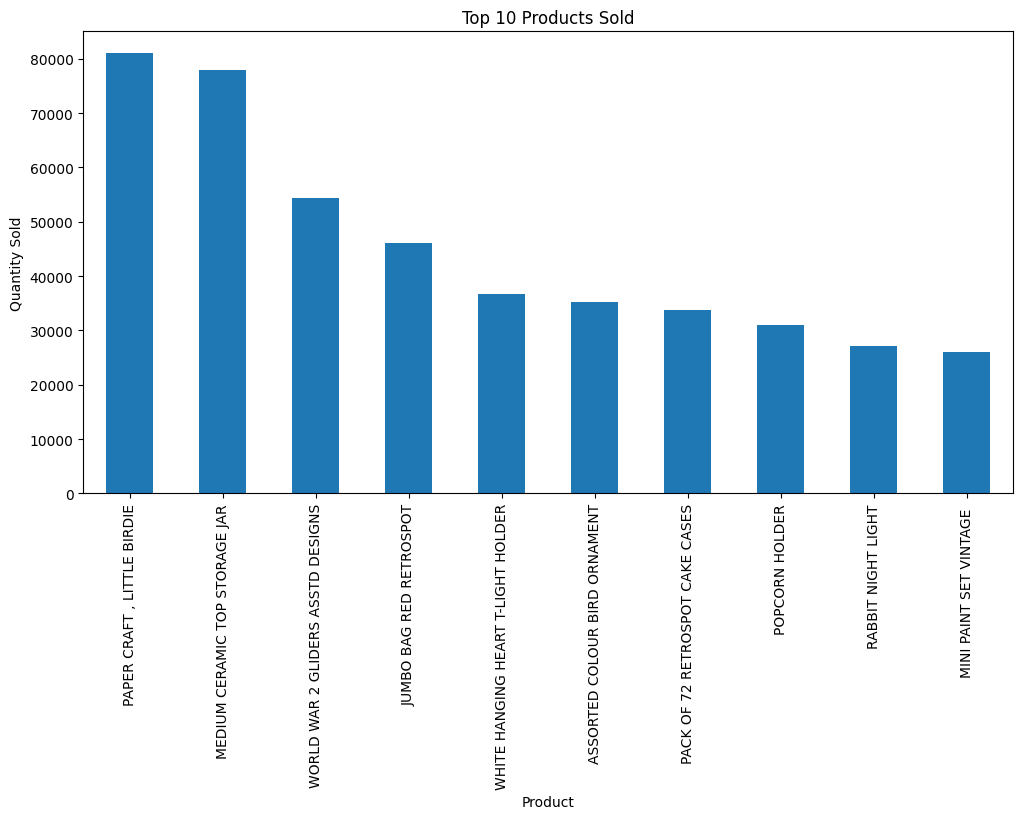

In [40]:
### Visualization 2: Top 10 Products Sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

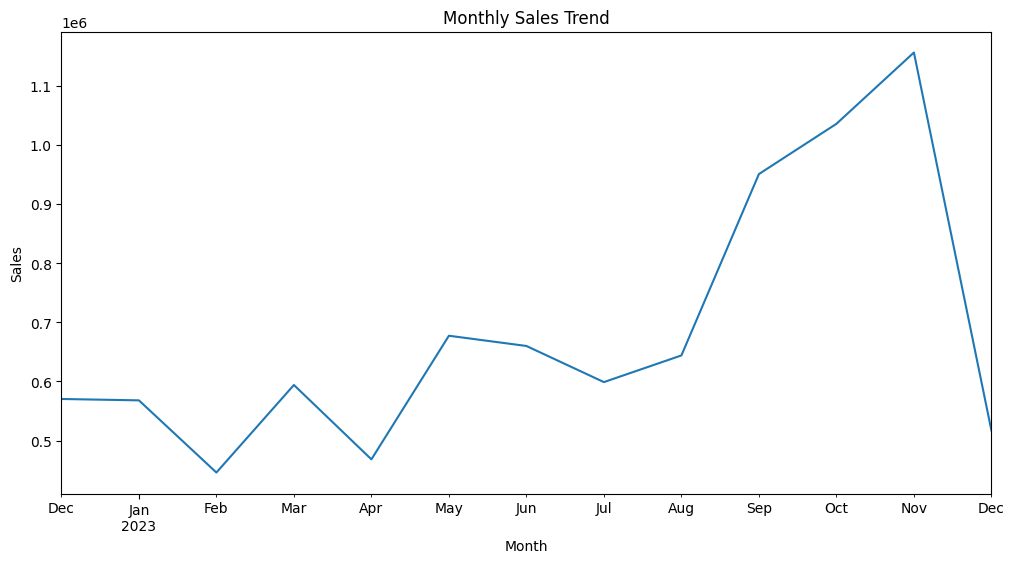

In [42]:
### Visualization 3: Monthly Sales Trend

### First create Month column:

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

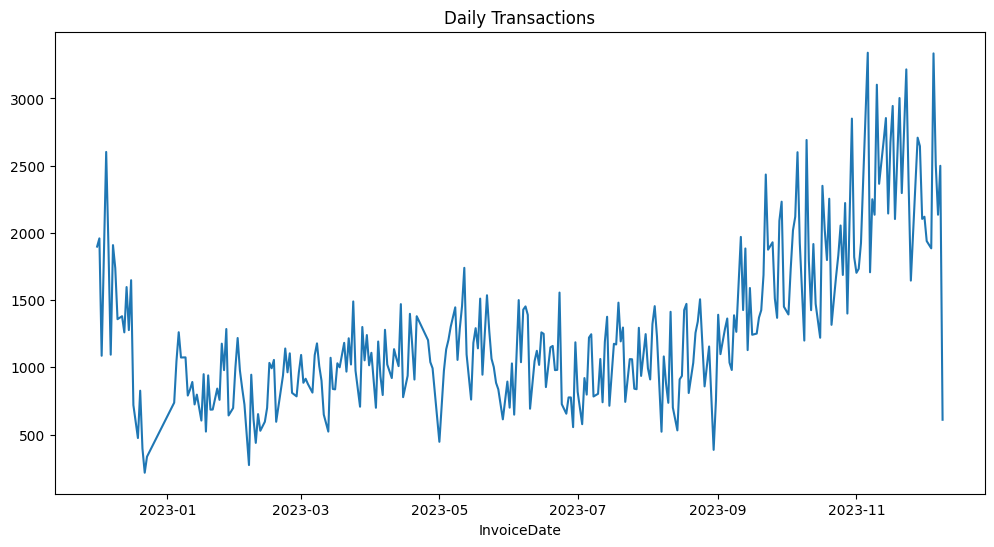

In [43]:
### Visualization 4: Daily Transactions
daily_transactions = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].count()

plt.figure(figsize=(12,6))

daily_transactions.plot()

plt.title("Daily Transactions")

plt.show()

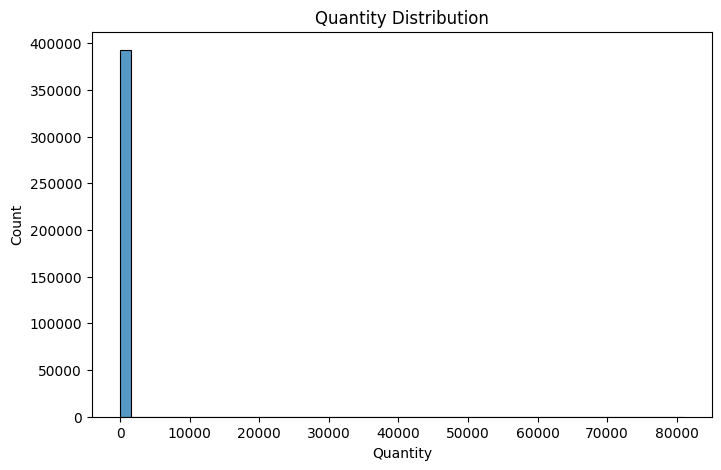

In [44]:
### Visualization 5: Quantity Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'], bins=50)

plt.title("Quantity Distribution")

plt.show()

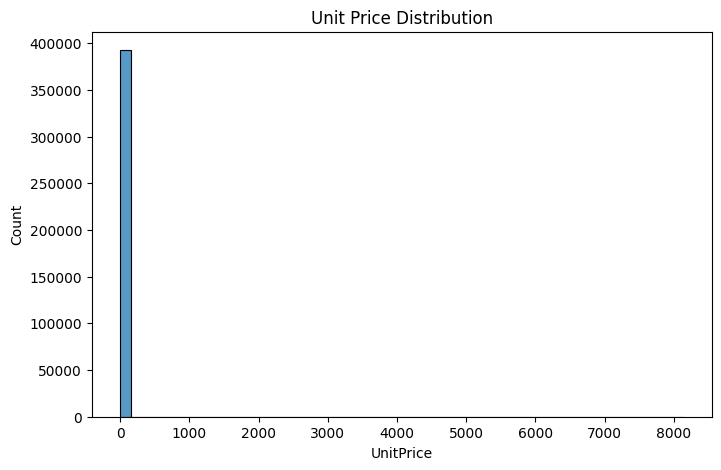

In [45]:
### Visualization 6: Unit Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['UnitPrice'], bins=50)

plt.title("Unit Price Distribution")

plt.show()

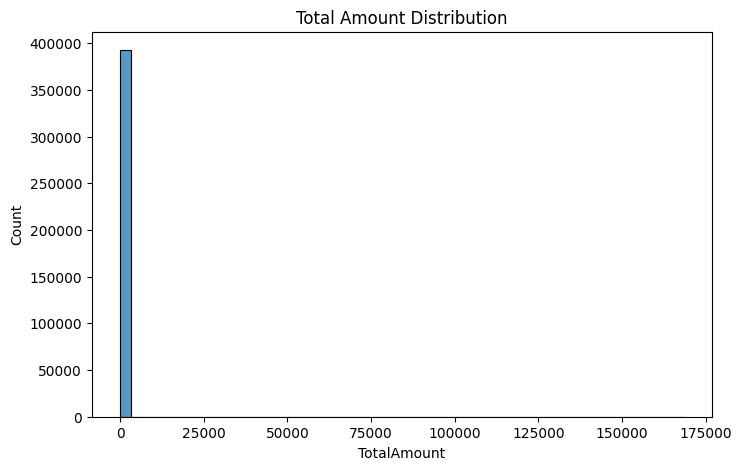

In [46]:
### Visualization 7: Total Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['TotalAmount'], bins=50)

plt.title("Total Amount Distribution")

plt.show()

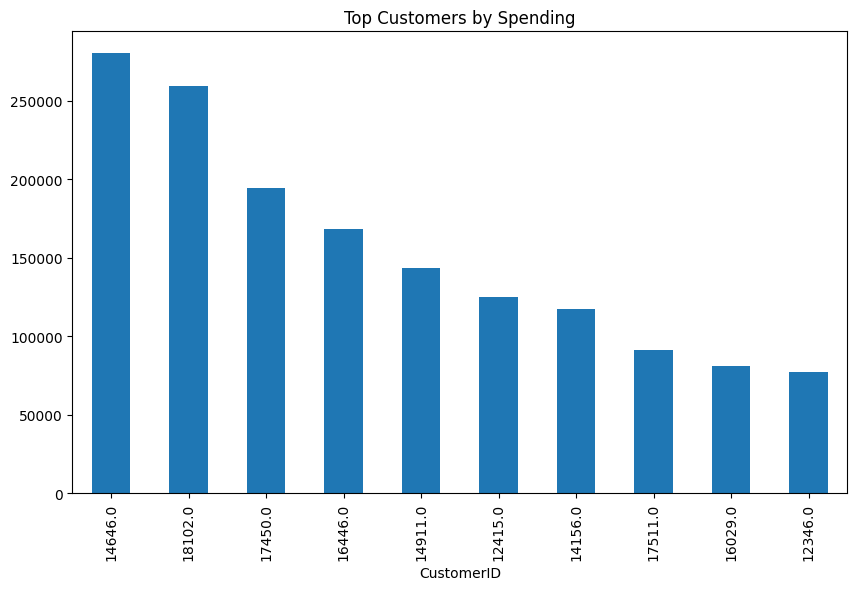

In [47]:
### Visualization 8: Top Customers by Spending
top_customers = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_customers.plot(kind='bar')

plt.title("Top Customers by Spending")

plt.show()

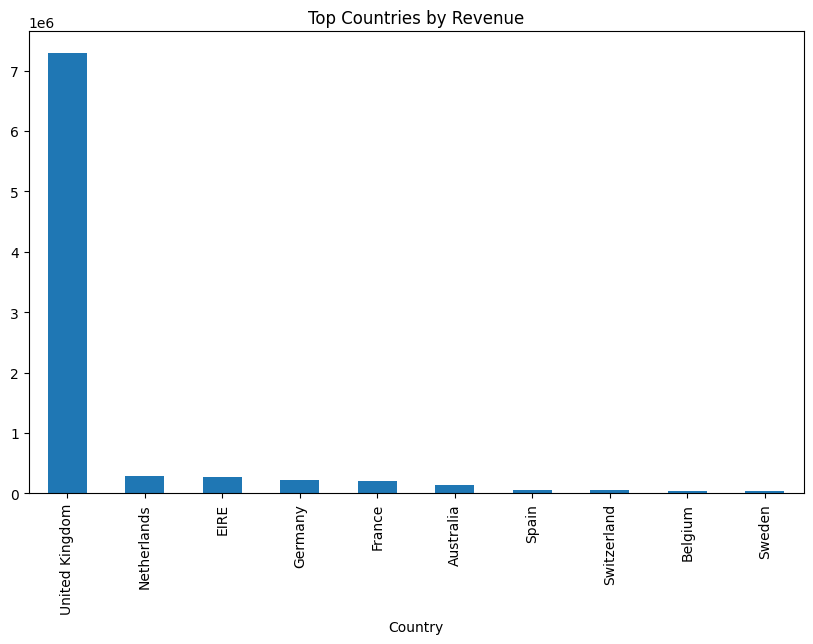

In [48]:
### Visualization 9: Top Countries by Revenue
country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

country_sales.plot(kind='bar')

plt.title("Top Countries by Revenue")

plt.show()

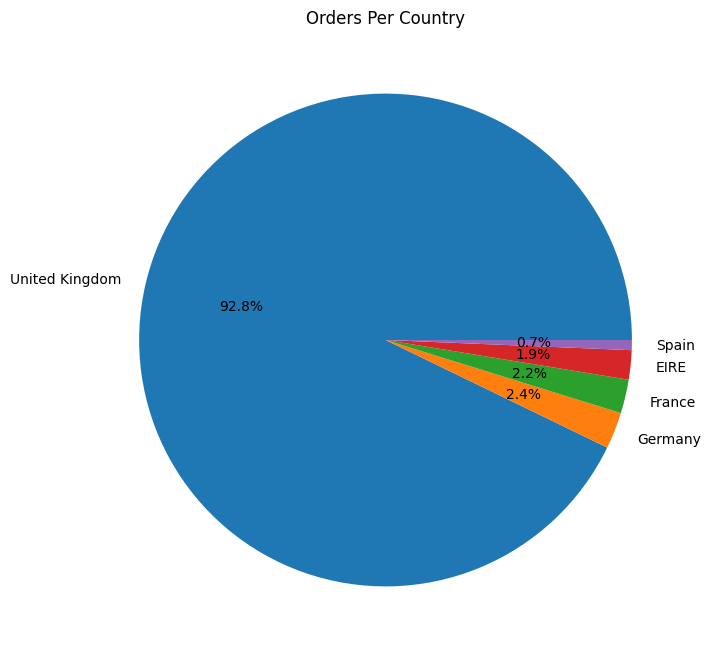

In [49]:
### Visualization 10: Orders Per Country (Pie Chart)
country_orders = df['Country'].value_counts().head(5)

plt.figure(figsize=(8,8))

country_orders.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel('')

plt.title("Orders Per Country")

plt.show()

In [73]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [74]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [75]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-12-10 12:50:00


In [76]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [77]:
rfm.columns = ['Recency','Frequency','Monetary']

In [78]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


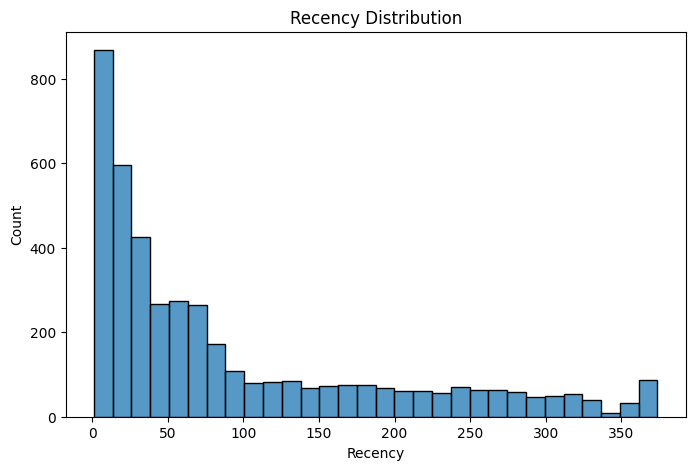

In [ ]:
### Visualization 11: Recency Distribution

plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=30)

plt.title("Recency Distribution")

plt.show()

In [61]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

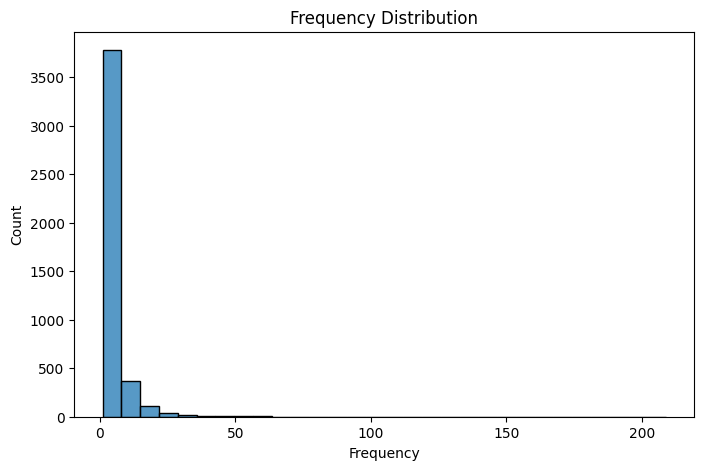

In [62]:
### Visualization 12: Frequency Distribution
plt.figure(figsize=(8,5))

sns.histplot(rfm['Frequency'], bins=30)

plt.title("Frequency Distribution")

plt.show()

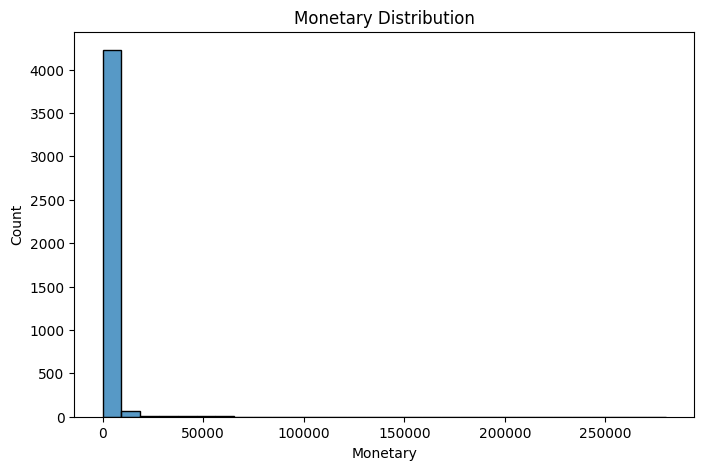

In [63]:
### Visualization 13: Monetary Distribution
plt.figure(figsize=(8,5))

sns.histplot(rfm['Monetary'], bins=30)

plt.title("Monetary Distribution")

plt.show()

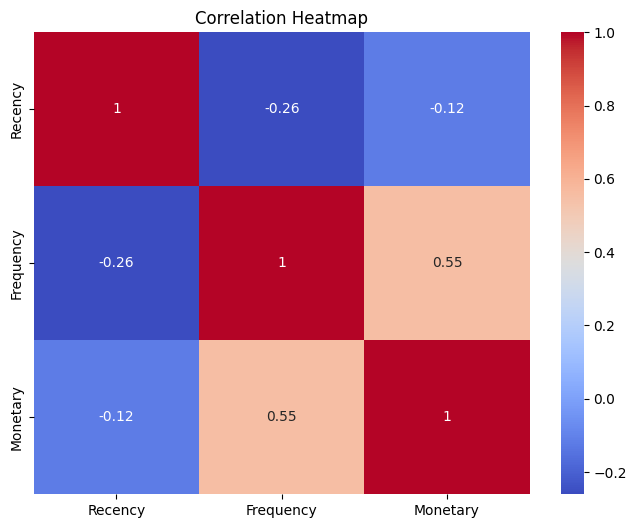

In [64]:
### Visualization 14: Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()

In [71]:
rfm_scaled = scaler.fit_transform(rfm)

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

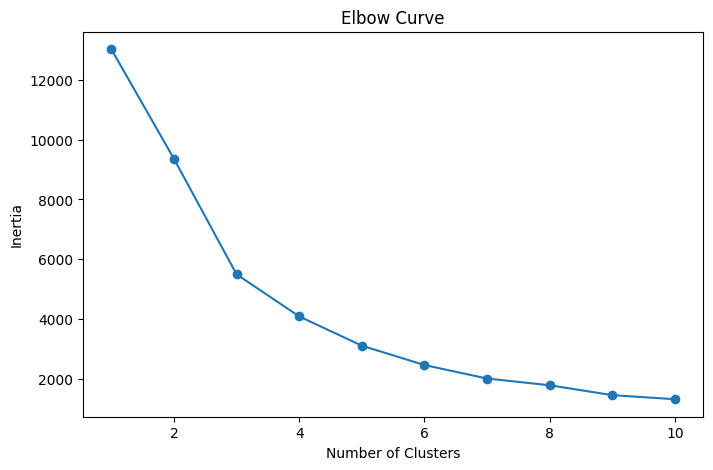

In [72]:
### Visualization 15: Elbow Curve

from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

    plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Curve")

plt.show()

In [24]:
### Top Selling Products

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

In [25]:
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


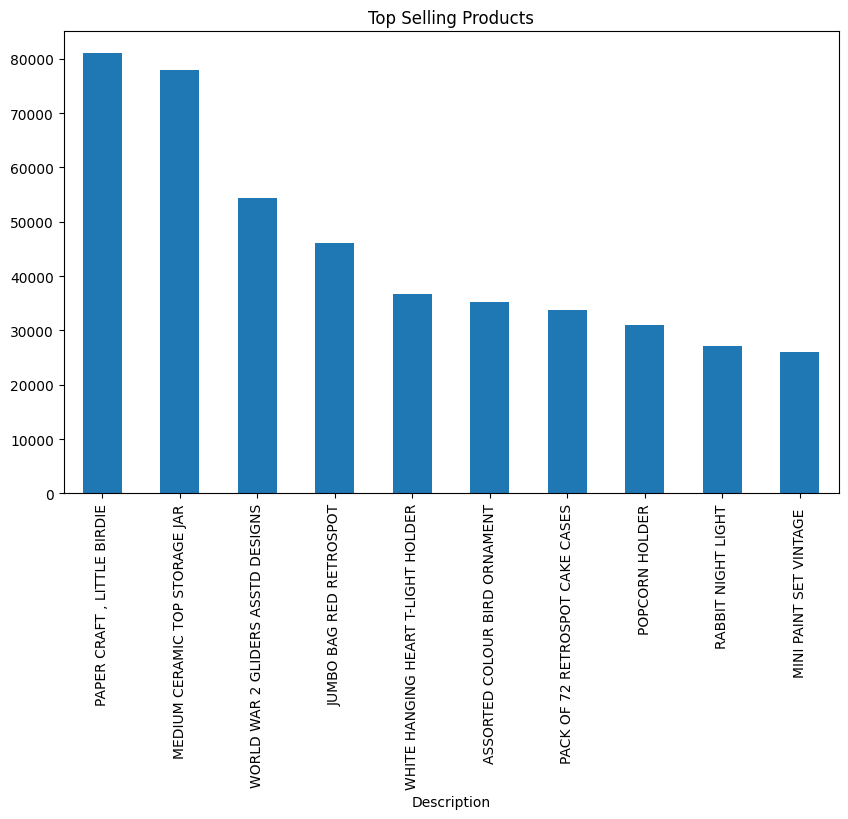

In [55]:
### Graph:- 

plt.figure(figsize=(10,6))

top_products.plot(kind='bar')

plt.title("Top Selling Products")

plt.show()

In [27]:
df['InvoiceDate'].max()

Timestamp('2023-12-09 12:50:00')

In [29]:
### Reference Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [30]:
### Calculate RFM

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [32]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [33]:
df['InvoiceDate'].max()

Timestamp('2023-12-09 12:50:00')

In [34]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [35]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [36]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [37]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


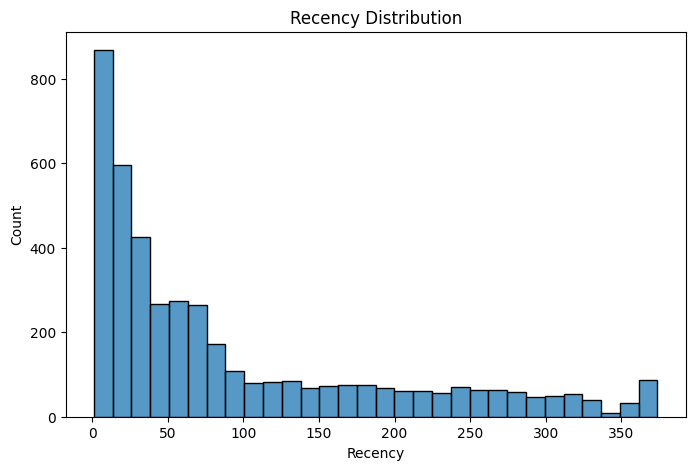

In [38]:
### Visualize RFM

### Recency Distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=30)

plt.title("Recency Distribution")

plt.show()